In [1]:
# ============================================================
# Regression 2-Source Evaluation Notebook
# ============================================================

import numpy as np
import pandas as pd
import torch
from torch import nn
import os
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# Plot style
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

print("Device:", DEVICE)

# Global config for evaluation
CONFIG = {
    "DATA_DIR": "../data/regression_2src",
    "TRAINING_DIR": "../models",
    "THRESHOLDS": [0.01, 0.02, 0.03, 0.04, 0.05],
    "NOISE_LEVELS": [0.0, 0.01, 0.03, 0.05, 0.10]
}

print("CONFIG loaded.")


Device: cpu
CONFIG loaded.


In [2]:
# ============================================================
# Load dataset + scalers
# ============================================================

DATASET_FILE = os.path.join(CONFIG["DATA_DIR"], "dataset_2src_fullfield_30obs_20k.npz")
SCALER_X_FILE = DATASET_FILE.replace(".npz", "_scaler_X.pkl")
SCALER_Y_FILE = DATASET_FILE.replace(".npz", "_scaler_Y.pkl")

print("Loading dataset from:", DATASET_FILE)

data = np.load(DATASET_FILE)

X_test  = data["X_test"]
Y_test  = data["Y_test"]

print("Dataset loaded.")
print("  X_test:", X_test.shape)
print("  Y_test:", Y_test.shape)

# Load scalers
scaler_X = joblib.load(SCALER_X_FILE)
scaler_Y = joblib.load(SCALER_Y_FILE)

print("Scalers loaded.")

# Convert to torch tensors
X_test_t = torch.tensor(X_test, dtype=torch.float64, device=DEVICE)
Y_test_t = torch.tensor(Y_test, dtype=torch.float64, device=DEVICE)

print("Tensors ready on device:", DEVICE)


Loading dataset from: ../data/regression_2src\dataset_2src_fullfield_30obs_20k.npz
Dataset loaded.
  X_test: (6000, 120)
  Y_test: (6000, 4)
Scalers loaded.
Tensors ready on device: cpu


In [3]:
# ============================================================
# Load trained model (best_model_2src.pth)
# ============================================================

model_path = os.path.join(CONFIG["TRAINING_DIR"], "best_model_2src.pth")
print("Loading model from:", model_path)

checkpoint = torch.load(model_path, map_location=DEVICE)

# Reconstruct the model class (same architecture as training)
class TwoSourcePredictor(nn.Module):
    def __init__(self, input_size, hidden_dims, output_size):
        super().__init__()
        layers = []
        prev = input_size

        for i, h in enumerate(hidden_dims):
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if i < 2:
                layers.append(nn.Dropout(0.05))
            prev = h

        layers.append(nn.Linear(prev, output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Instantiate model with saved architecture
model = TwoSourcePredictor(
    input_size=checkpoint["input_size"],
    hidden_dims=checkpoint["hidden_dims"],
    output_size=checkpoint["output_size"]
).to(torch.float64).to(DEVICE)

# Load weights
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded and ready for evaluation.")


Loading model from: ../models\best_model_2src.pth
Model loaded and ready for evaluation.


In [4]:
# ============================================================
# Zero‑Noise Evaluation
# ============================================================

def angle_np(a, b):
    """Compute angular error between 2D vectors using numpy."""
    dot = np.sum(a * b, axis=1)
    na = np.linalg.norm(a, axis=1)
    nb = np.linalg.norm(b, axis=1)
    cos = np.clip(dot / (na * nb + 1e-8), -1 + 1e-6, 1 - 1e-6)
    return np.arccos(cos)

def evaluate_zero_noise(model, X_test_t, Y_test):
    """Run model on clean test set and compute all primary errors."""
    with torch.no_grad():
        preds = model(X_test_t).cpu().numpy()

    # Distance errors
    distA = np.linalg.norm(preds[:, 0:2] - Y_test[:, 0:2], axis=1)
    distB = np.linalg.norm(preds[:, 2:4] - Y_test[:, 2:4], axis=1)

    # Angular errors
    angleA = angle_np(preds[:, 0:2], Y_test[:, 0:2])
    angleB = angle_np(preds[:, 2:4], Y_test[:, 2:4])

    # Area consistency
    pred_area = np.abs(preds[:, 0] * preds[:, 3] - preds[:, 1] * preds[:, 2])
    true_area = np.abs(Y_test[:, 0] * Y_test[:, 3] - Y_test[:, 1] * Y_test[:, 2])
    area_err = np.abs(pred_area - true_area)

    return preds, distA, distB, angleA, angleB, area_err


# Run evaluation
preds, distA, distB, angleA, angleB, area_err = evaluate_zero_noise(model, X_test_t, Y_test)

print("Zero‑noise evaluation complete.")
print("Mean distA:", distA.mean())
print("Mean distB:", distB.mean())
print("Mean angleA:", angleA.mean())
print("Mean angleB:", angleB.mean())
print("Mean area error:", area_err.mean())


Zero‑noise evaluation complete.
Mean distA: 0.009543506072684824
Mean distB: 0.007897521142824956
Mean angleA: 0.009428202463200627
Mean angleB: 0.007256555189595017
Mean area error: 0.006350127521199321


In [5]:
# ============================================================
# Unified R² Metrics (distances, ρ, φ)
# ============================================================

def circ_r2(phi_true, phi_pred):
    """
    Circular R² for angular variables.
    """
    phi_true = np.angle(np.exp(1j * phi_true))
    phi_pred = np.angle(np.exp(1j * phi_pred))

    mean_true = np.angle(np.mean(np.exp(1j * phi_true)))
    mean_pred = np.angle(np.mean(np.exp(1j * phi_pred)))

    num = np.sum(np.sin(phi_true - mean_true) * np.sin(phi_pred - mean_pred))
    den = np.sqrt(
        np.sum(np.sin(phi_true - mean_true)**2) *
        np.sum(np.sin(phi_pred - mean_pred)**2)
    )

    return (num / den)**2


def compute_r2_rho_phi(preds, targets):
    """
    Compute R² for:
        - radial distance ρ
        - angle φ
    for both sources A and B.
    """

    # Radii
    rho_true_A = np.linalg.norm(targets[:, 0:2], axis=1)
    rho_pred_A = np.linalg.norm(preds[:, 0:2], axis=1)

    rho_true_B = np.linalg.norm(targets[:, 2:4], axis=1)
    rho_pred_B = np.linalg.norm(preds[:, 2:4], axis=1)

    r2_rho_A = r2_score(rho_true_A, rho_pred_A)
    r2_rho_B = r2_score(rho_true_B, rho_pred_B)

    # Angles
    phi_true_A = np.arctan2(targets[:, 1], targets[:, 0])
    phi_pred_A = np.arctan2(preds[:, 1], preds[:, 0])

    phi_true_B = np.arctan2(targets[:, 3], targets[:, 2])
    phi_pred_B = np.arctan2(preds[:, 3], preds[:, 2])

    circR2_A = circ_r2(phi_true_A, phi_pred_A)
    circR2_B = circ_r2(phi_true_B, phi_pred_B)

    return r2_rho_A, r2_rho_B, circR2_A, circR2_B


# ------------------------------------------------------------
# Compute all R² metrics
# ------------------------------------------------------------

# Distances: linear R² on flattened coordinates
r2_distA = r2_score(Y_test[:, 0:2].reshape(-1), preds[:, 0:2].reshape(-1))
r2_distB = r2_score(Y_test[:, 2:4].reshape(-1), preds[:, 2:4].reshape(-1))

# Radii & angles
r2_rho_A, r2_rho_B, circR2_A, circR2_B = compute_r2_rho_phi(preds, Y_test)

# Unified table
r2_table = pd.DataFrame({
    "Metric": ["dist1", "dist2", "rho1", "rho2", "phi1", "phi2"],
    "R2": [r2_distA, r2_distB, r2_rho_A, r2_rho_B, circR2_A, circR2_B]
})

print("=== Unified R² Table (dist, rho, phi) ===")
display(r2_table)


=== Unified R² Table (dist, rho, phi) ===


,Metric,R2
0,dist1,0.995324
1,dist2,0.998619
2,rho1,0.996705
3,rho2,0.998823
4,phi1,0.994740
5,phi2,0.998704


In [6]:
# ============================================================
# d_max Metrics (mean, std, percentiles)
# ============================================================

def compute_dmax(distA, distB):
    """
    Compute d_max = max(distA, distB) and summary statistics.
    """
    dmax = np.maximum(distA, distB)

    percentiles = [50, 90, 95, 99, 99.5, 99.9]
    dmax_perc = {f"p{p}": np.percentile(dmax, p) for p in percentiles}

    summary = {
        "mean_dmax": dmax.mean(),
        "std_dmax": dmax.std(),
        **dmax_perc
    }

    return dmax, summary


# Run d_max evaluation
dmax, dmax_summary = compute_dmax(distA, distB)

dmax_df = pd.DataFrame([dmax_summary])

print("=== d_max Summary ===")
display(dmax_df)


=== d_max Summary ===


,mean_dmax,std_dmax,p50,p90,p95,p99,p99.5,p99.9
0,0.011163,0.012327,0.009914,0.016029,0.018645,0.034764,0.057093,0.135417


In [7]:
# ============================================================
# Noise Robustness Evaluation
# ============================================================

def evaluate_noise(model, X_test, Y_test, noise_levels):
    """
    Evaluate model robustness under Gaussian noise added to X_test.
    Noise is scaled by the feature-wise standard deviation.
    """
    X_std = X_test.std(axis=0) + 1e-8
    results = []

    for sigma in noise_levels:
        # Add Gaussian noise
        noise = np.random.randn(*X_test.shape) * (sigma * X_std)
        X_noisy = X_test + noise

        # Convert to tensor
        X_noisy_t = torch.tensor(X_noisy, dtype=torch.float64, device=DEVICE)

        # Predict
        with torch.no_grad():
            preds_n = model(X_noisy_t).cpu().numpy()

        # Compute errors
        distA_n = np.linalg.norm(preds_n[:, 0:2] - Y_test[:, 0:2], axis=1)
        distB_n = np.linalg.norm(preds_n[:, 2:4] - Y_test[:, 2:4], axis=1)
        dmax_n = np.maximum(distA_n, distB_n)

        # Store summary
        results.append({
            "noise_sigma": sigma,
            "mean_dmax": dmax_n.mean(),
            "p99_dmax": np.quantile(dmax_n, 0.99)
        })

    return pd.DataFrame(results)


# Run noise robustness evaluation
noise_df = evaluate_noise(model, X_test, Y_test, CONFIG["NOISE_LEVELS"])

print("=== Noise Robustness Summary ===")
display(noise_df)


=== Noise Robustness Summary ===


,noise_sigma,mean_dmax,p99_dmax
0,0.00,0.011163,0.034764
1,0.01,0.011173,0.034958
2,0.03,0.011298,0.035512
3,0.05,0.011500,0.035497
4,0.10,0.012442,0.039455


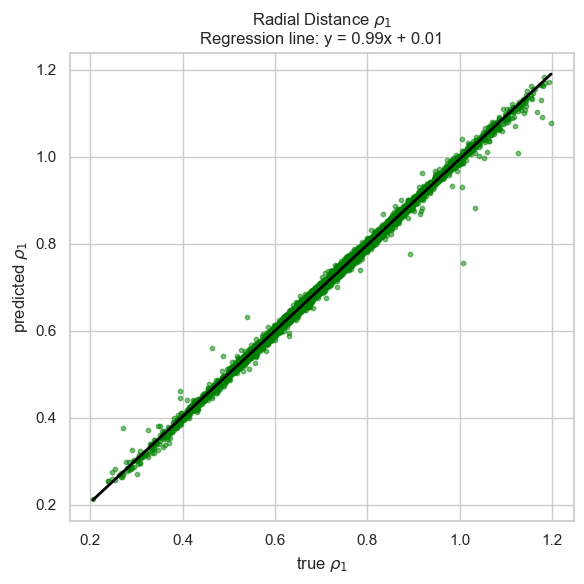

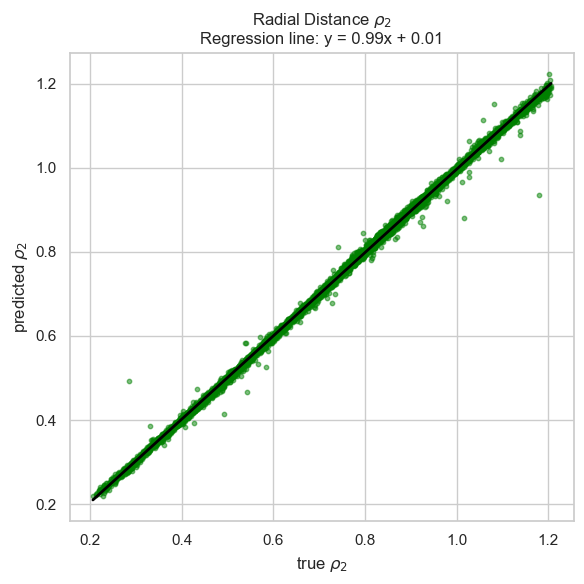

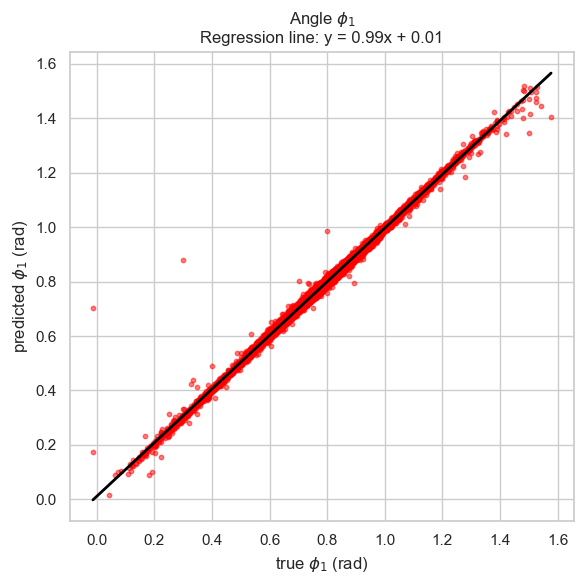

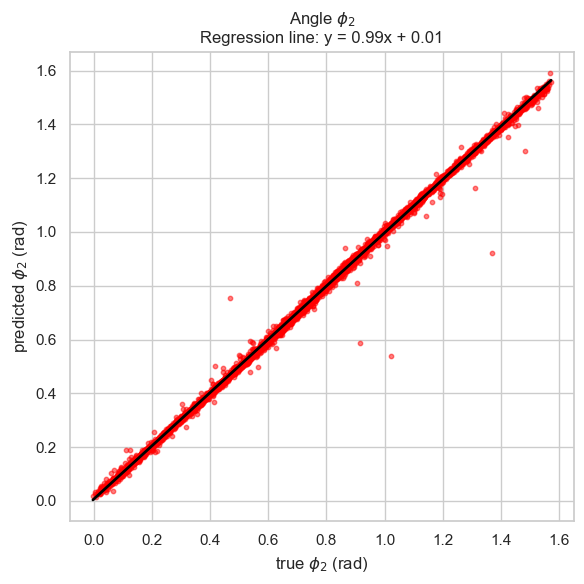

In [8]:
# ============================================================
# Scatter Plots with Regression Lines (ρ and φ) — LaTeX subscripts
# ============================================================

def scatter_with_regression(x, y, title, xlabel, ylabel, color, filename):
    """
    Scatter plot with regression line.
    Saves PNG and displays inline.
    """
    plt.style.use("default")
    sns.set_theme(style="whitegrid")

    fig = plt.figure(figsize=(6, 6))
    ax = plt.gca()

    # Scatter
    plt.scatter(x, y, s=10, alpha=0.5, color=color)

    # Regression line
    model_lr = LinearRegression().fit(x.reshape(-1, 1), y)
    a = model_lr.coef_[0]
    b = model_lr.intercept_

    xx = np.linspace(x.min(), x.max(), 200)
    yy = a * xx + b
    plt.plot(xx, yy, color="black", linewidth=2)

    plt.title(f"{title}\nRegression line: y = {a:.2f}x + {b:.2f}")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.show()


# ------------------------------------------------------------
# Prepare true/pred values for ρ and φ
# ------------------------------------------------------------

rho_true_A = np.linalg.norm(Y_test[:, 0:2], axis=1)
rho_pred_A = np.linalg.norm(preds[:, 0:2], axis=1)

rho_true_B = np.linalg.norm(Y_test[:, 2:4], axis=1)
rho_pred_B = np.linalg.norm(preds[:, 2:4], axis=1)

phi_true_A = np.arctan2(Y_test[:, 1], Y_test[:, 0])
phi_pred_A = np.arctan2(preds[:, 1], preds[:, 0])

phi_true_B = np.arctan2(Y_test[:, 3], Y_test[:, 2])
phi_pred_B = np.arctan2(preds[:, 3], preds[:, 2])


# ------------------------------------------------------------
# Generate scatter plots (LaTeX subscripts)
# ------------------------------------------------------------

scatter_with_regression(
    rho_true_A, rho_pred_A,
    r"Radial Distance $\rho_1$", r"true $\rho_1$", r"predicted $\rho_1$",
    "green", "rho_1.png"
)

scatter_with_regression(
    rho_true_B, rho_pred_B,
    r"Radial Distance $\rho_2$", r"true $\rho_2$", r"predicted $\rho_2$",
    "green", "rho_2.png"
)

scatter_with_regression(
    phi_true_A, phi_pred_A,
    r"Angle $\phi_1$", r"true $\phi_1$ (rad)", r"predicted $\phi_1$ (rad)",
    "red", "phi_1.png"
)

scatter_with_regression(
    phi_true_B, phi_pred_B,
    r"Angle $\phi_2$", r"true $\phi_2$ (rad)", r"predicted $\phi_2$ (rad)",
    "red", "phi_2.png"
)


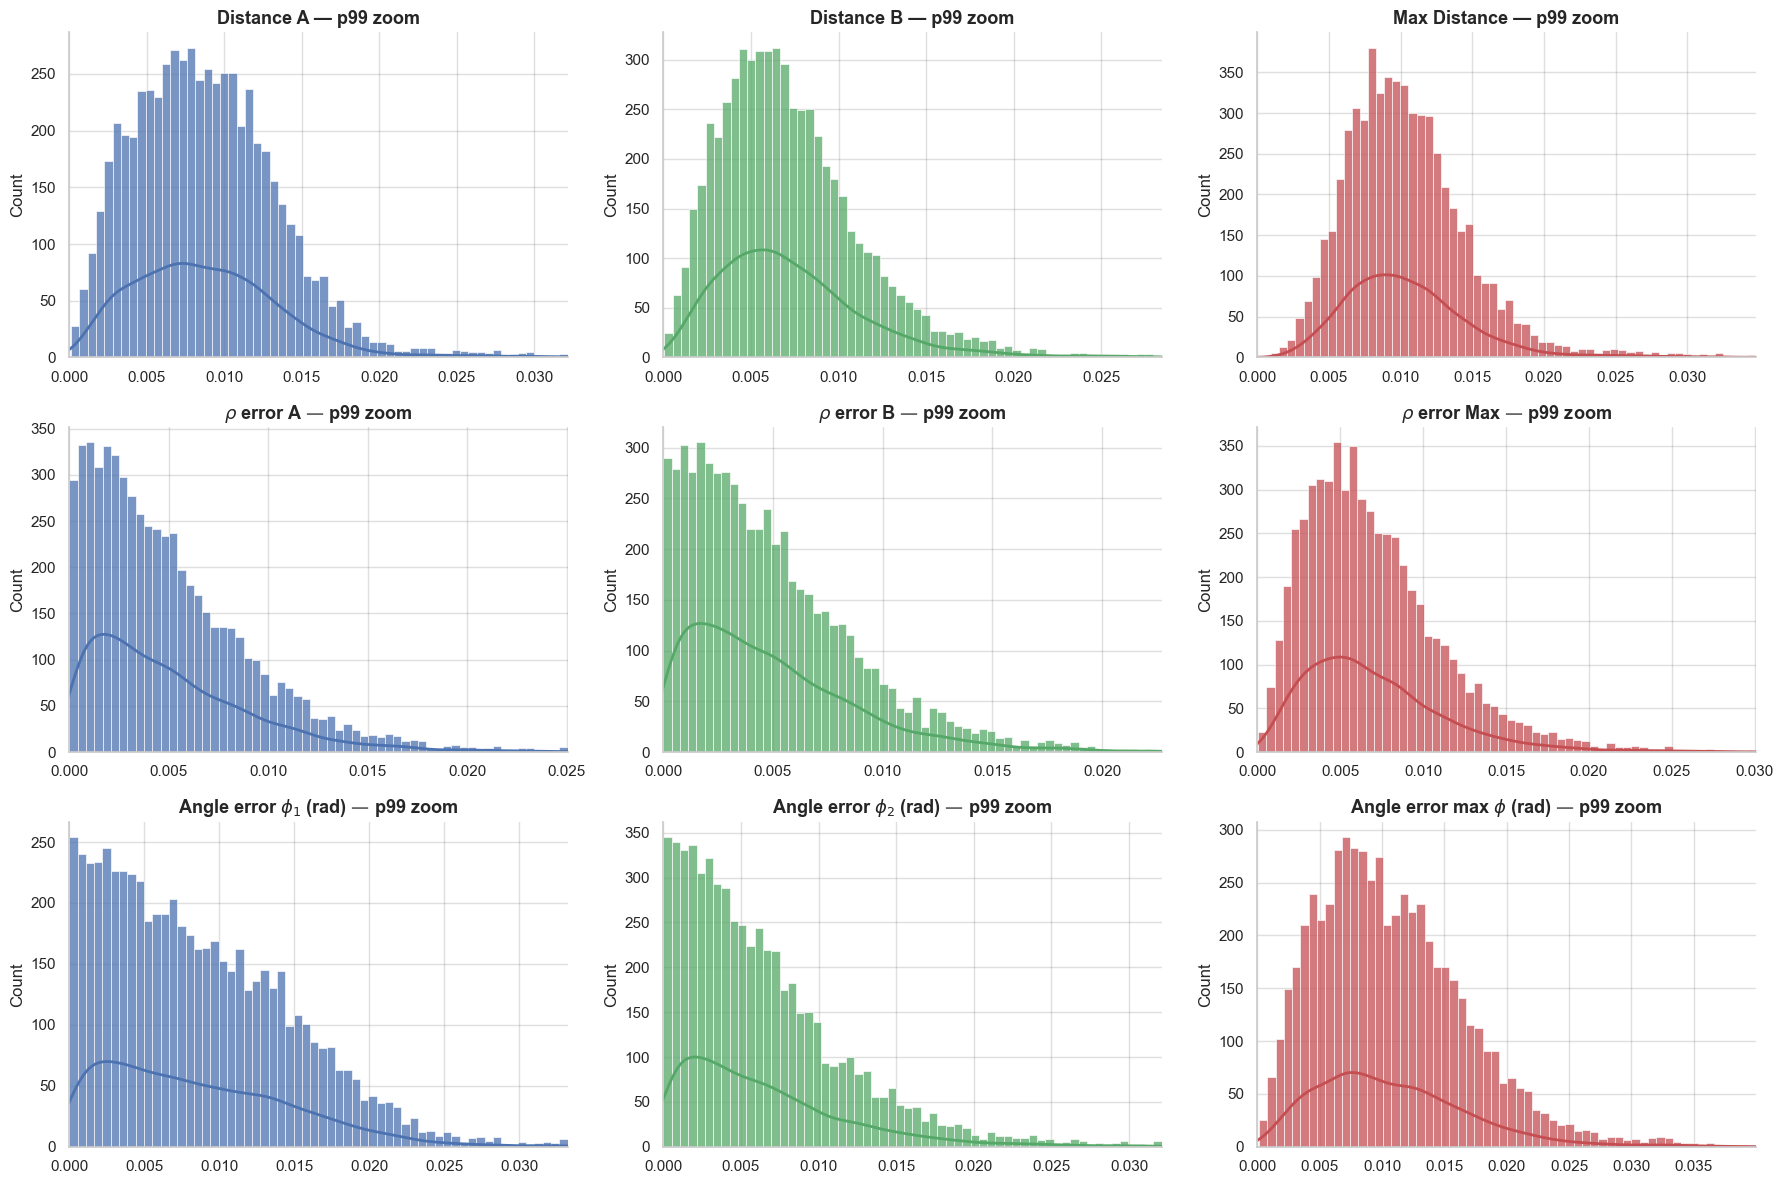

In [9]:
# ============================================================
# 3×3 Grid: Distance, ρ-error, φ-error (A, B, Max)
# p99 zoom + save PNG files — LaTeX subscripts
# ============================================================

plt.style.use("default")
sns.set_theme(style="whitegrid")

# -----------------------------
# 1. Distances
# -----------------------------
distA_vals = distA
distB_vals = distB
distMax_vals = np.maximum(distA, distB)

# -----------------------------
# 2. Radii ρ errors
# -----------------------------
rho_true_A = np.linalg.norm(Y_test[:, 0:2], axis=1)
rho_pred_A = np.linalg.norm(preds[:, 0:2], axis=1)

rho_true_B = np.linalg.norm(Y_test[:, 2:4], axis=1)
rho_pred_B = np.linalg.norm(preds[:, 2:4], axis=1)

rho_err_A = np.abs(rho_pred_A - rho_true_A)
rho_err_B = np.abs(rho_pred_B - rho_true_B)
rho_err_Max = np.maximum(rho_err_A, rho_err_B)

# -----------------------------
# 3. Angle φ errors
# -----------------------------
phi_true_A = np.arctan2(Y_test[:, 1], Y_test[:, 0])
phi_pred_A = np.arctan2(preds[:, 1], preds[:, 0])

phi_true_B = np.arctan2(Y_test[:, 3], Y_test[:, 2])
phi_pred_B = np.arctan2(preds[:, 3], preds[:, 2])

phi_err_A = np.abs(np.angle(np.exp(1j * (phi_pred_A - phi_true_A))))
phi_err_B = np.abs(np.angle(np.exp(1j * (phi_pred_B - phi_true_B))))
phi_err_Max = np.maximum(phi_err_A, phi_err_B)

# -----------------------------
# 4. 3×3 structure with LaTeX
# -----------------------------
grid_data = [
    [(r"Distance A", distA_vals, "dist_A.png"),
     (r"Distance B", distB_vals, "dist_B.png"),
     (r"Max Distance", distMax_vals, "dist_max.png")],

    [(r"$\rho$ error A", rho_err_A, "rho_err_A.png"),
     (r"$\rho$ error B", rho_err_B, "rho_err_B.png"),
     (r"$\rho$ error Max", rho_err_Max, "rho_err_max.png")],

    [(r"Angle error $\phi_1$ (rad)", phi_err_A, "phi_err_A.png"),
     (r"Angle error $\phi_2$ (rad)", phi_err_B, "phi_err_B.png"),
     (r"Angle error max $\phi$ (rad)", phi_err_Max, "phi_err_max.png")]
]

colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row in range(3):
    for col in range(3):

        title, values, filename = grid_data[row][col]
        ax = axes[row, col]
        color = colors[col]

        p99 = np.percentile(values, 99)
        zoom_vals = values[values <= p99]

        sns.histplot(zoom_vals, bins=60, kde=False, color=color, alpha=0.75, ax=ax)
        sns.kdeplot(zoom_vals, color=color, linewidth=2, ax=ax)

        ax.set_title(f"{title} — p99 zoom", fontsize=13, weight="bold")
        ax.set_xlim(0, p99)
        ax.grid(True, color="gray", alpha=0.25)
        sns.despine(ax=ax)

        fig_single, ax_single = plt.subplots(figsize=(6, 4))
        sns.histplot(zoom_vals, bins=60, kde=False, color=color, alpha=0.75, ax=ax_single)
        sns.kdeplot(zoom_vals, color=color, linewidth=2, ax=ax_single)
        ax_single.set_title(f"{title} — p99 zoom", fontsize=13, weight="bold")
        ax_single.set_xlim(0, p99)
        ax_single.grid(True, color="gray", alpha=0.25)
        sns.despine(ax=ax_single)
        plt.tight_layout()
        # fig_single.savefig(filename, dpi=300)
        plt.close(fig_single)

plt.tight_layout()
plt.show()


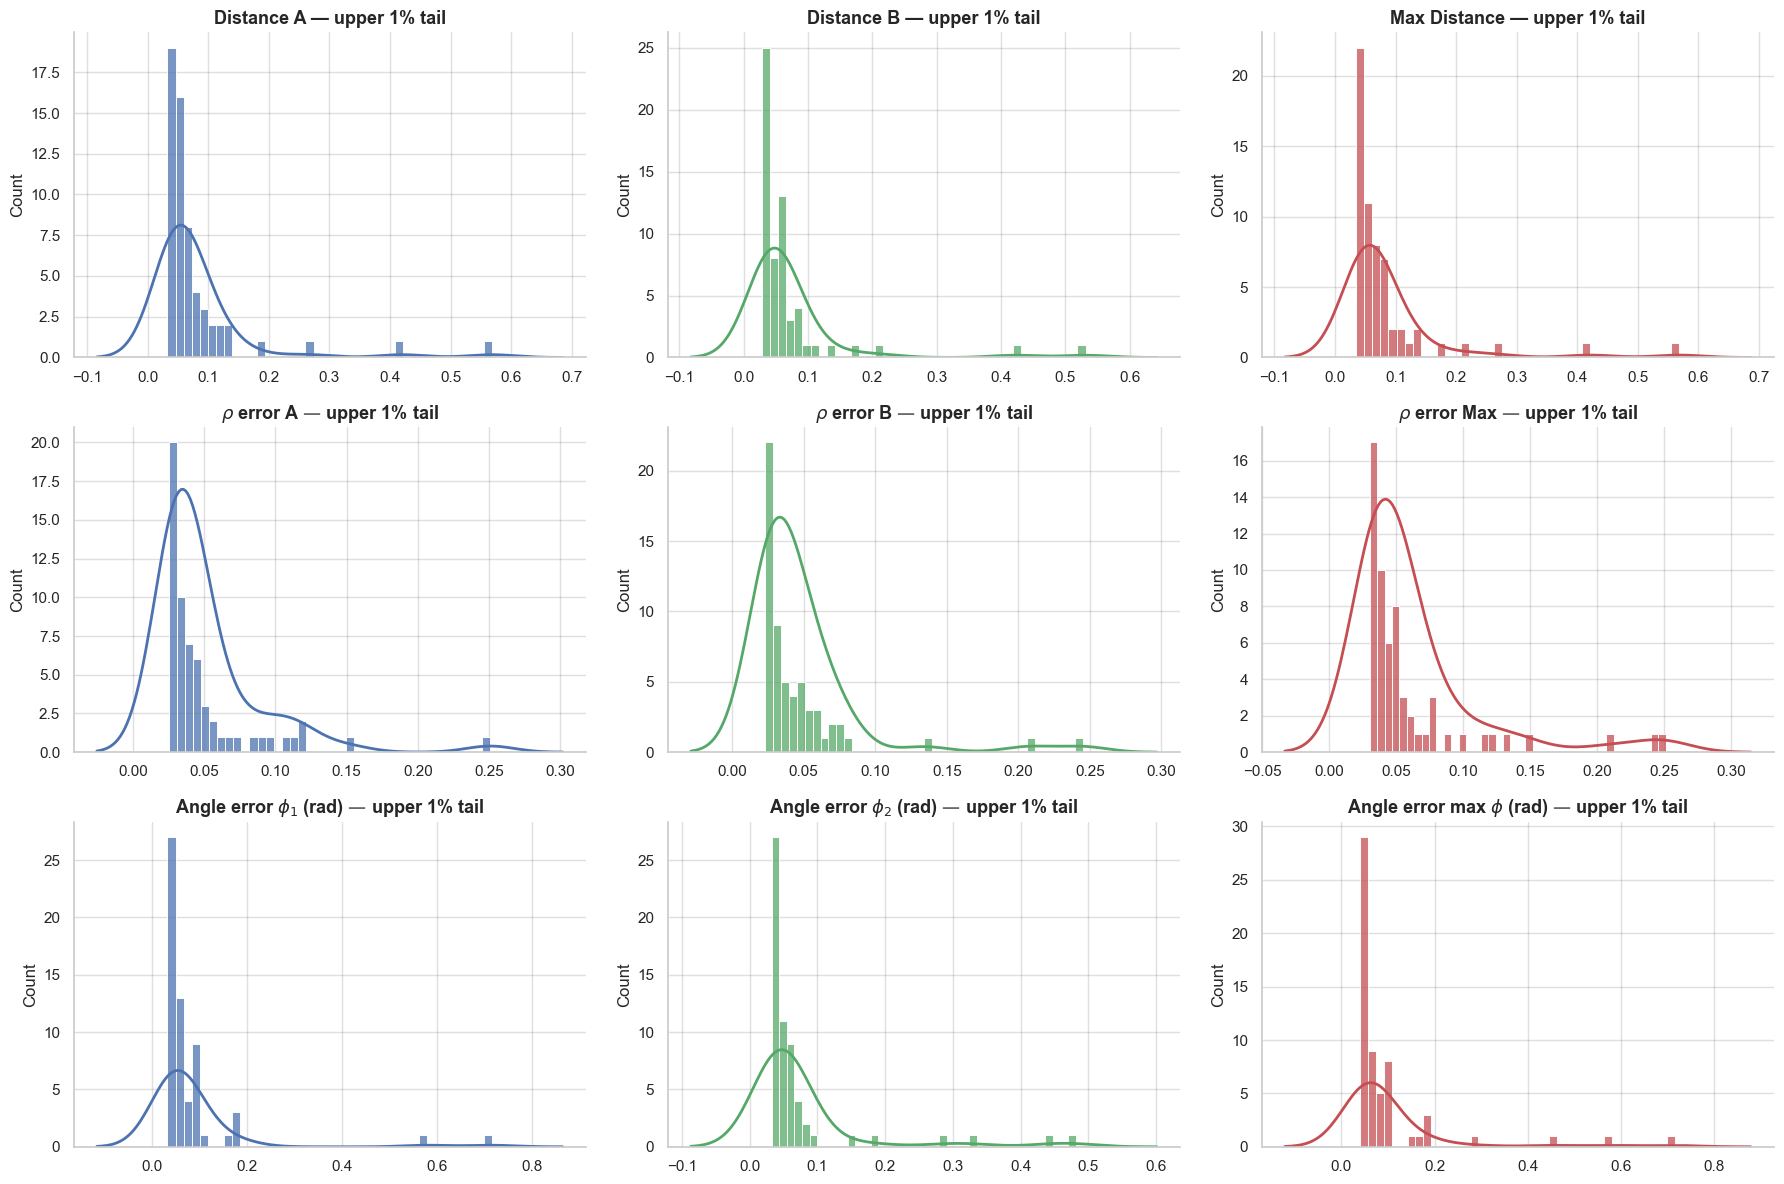

In [10]:
# ============================================================
# 3×3 Grid: Distance, ρ-error, φ-error (A, B, Max)
# Upper 1% tail + save PNG files — LaTeX subscripts
# ============================================================

plt.style.use("default")
sns.set_theme(style="whitegrid")

# -----------------------------
# 1. Distances
# -----------------------------
distA_vals = distA
distB_vals = distB
distMax_vals = np.maximum(distA, distB)

# -----------------------------
# 2. Radii ρ errors
# -----------------------------
rho_true_A = np.linalg.norm(Y_test[:, 0:2], axis=1)
rho_pred_A = np.linalg.norm(preds[:, 0:2], axis=1)

rho_true_B = np.linalg.norm(Y_test[:, 2:4], axis=1)
rho_pred_B = np.linalg.norm(preds[:, 2:4], axis=1)

rho_err_A = np.abs(rho_pred_A - rho_true_A)
rho_err_B = np.abs(rho_pred_B - rho_true_B)
rho_err_Max = np.maximum(rho_err_A, rho_err_B)

# -----------------------------
# 3. Angle φ errors
# -----------------------------
phi_true_A = np.arctan2(Y_test[:, 1], Y_test[:, 0])
phi_pred_A = np.arctan2(preds[:, 1], preds[:, 0])

phi_true_B = np.arctan2(Y_test[:, 3], Y_test[:, 2])
phi_pred_B = np.arctan2(preds[:, 3], preds[:, 2])

phi_err_A = np.abs(np.angle(np.exp(1j * (phi_pred_A - phi_true_A))))
phi_err_B = np.abs(np.angle(np.exp(1j * (phi_pred_B - phi_true_B))))
phi_err_Max = np.maximum(phi_err_A, phi_err_B)

# -----------------------------
# 4. 3×3 structure with LaTeX
# -----------------------------
grid_data = [
    [(r"Distance A", distA_vals, "dist_A_tail.png"),
     (r"Distance B", distB_vals, "dist_B_tail.png"),
     (r"Max Distance", distMax_vals, "dist_max_tail.png")],

    [(r"$\rho$ error A", rho_err_A, "rho_err_A_tail.png"),
     (r"$\rho$ error B", rho_err_B, "rho_err_B_tail.png"),
     (r"$\rho$ error Max", rho_err_Max, "rho_err_max_tail.png")],

    [(r"Angle error $\phi_1$ (rad)", phi_err_A, "phi_err_A_tail.png"),
     (r"Angle error $\phi_2$ (rad)", phi_err_B, "phi_err_B_tail.png"),
     (r"Angle error max $\phi$ (rad)", phi_err_Max, "phi_err_max_tail.png")]
]

colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row in range(3):
    for col in range(3):

        title, values, filename = grid_data[row][col]
        ax = axes[row, col]
        color = colors[col]

        p99 = np.percentile(values, 99)
        tail_vals = values[values > p99]

        sns.histplot(tail_vals, bins=40, kde=False, color=color, alpha=0.75, ax=ax)

        if len(tail_vals) > 1:
            sns.kdeplot(tail_vals, color=color, linewidth=2, ax=ax)

        ax.set_title(f"{title} — upper 1% tail", fontsize=13, weight="bold")
        ax.grid(True, color="gray", alpha=0.25)
        sns.despine(ax=ax)

        fig_single, ax_single = plt.subplots(figsize=(6, 4))
        sns.histplot(tail_vals, bins=40, kde=False, color=color, alpha=0.75, ax=ax_single)
        if len(tail_vals) > 1:
            sns.kdeplot(tail_vals, color=color, linewidth=2, ax=ax_single)
        ax_single.set_title(f"{title} — upper 1% tail", fontsize=13, weight="bold")
        ax_single.grid(True, color="gray", alpha=0.25)
        sns.despine(ax=ax_single)
        plt.tight_layout()
        # fig_single.savefig(filename, dpi=300)
        plt.close(fig_single)

plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# Full Metrics Table for All Error Quantities
# ============================================================

def compute_all_metrics(preds, Y_test):
    # -----------------------------
    # 1. Distances
    # -----------------------------
    d_A = np.linalg.norm(preds[:, 0:2] - Y_test[:, 0:2], axis=1)
    d_B = np.linalg.norm(preds[:, 2:4] - Y_test[:, 2:4], axis=1)
    d_max = np.maximum(d_A, d_B)

    # -----------------------------
    # 2. Radii and radius errors
    # -----------------------------
    rho_A_true = np.linalg.norm(Y_test[:, 0:2], axis=1)
    rho_A_pred = np.linalg.norm(preds[:, 0:2], axis=1)
    rho_B_true = np.linalg.norm(Y_test[:, 2:4], axis=1)
    rho_B_pred = np.linalg.norm(preds[:, 2:4], axis=1)

    e_rho_A = np.abs(rho_A_pred - rho_A_true)
    e_rho_B = np.abs(rho_B_pred - rho_B_true)
    e_rho_max = np.maximum(e_rho_A, e_rho_B)

    # -----------------------------
    # 3. Angles and angle errors
    # -----------------------------
    phi_A_true = np.arctan2(Y_test[:, 1], Y_test[:, 0])
    phi_A_pred = np.arctan2(preds[:, 1], preds[:, 0])

    phi_B_true = np.arctan2(Y_test[:, 3], Y_test[:, 2])
    phi_B_pred = np.arctan2(preds[:, 3], preds[:, 2])

    e_phi_A = np.abs(np.angle(np.exp(1j * (phi_A_pred - phi_A_true))))
    e_phi_B = np.abs(np.angle(np.exp(1j * (phi_B_pred - phi_B_true))))
    e_phi_max = np.maximum(e_phi_A, e_phi_B)

    # -----------------------------
    # 4. R² values
    # -----------------------------
    r2_distA = r2_score(Y_test[:, 0:2].reshape(-1), preds[:, 0:2].reshape(-1))
    r2_distB = r2_score(Y_test[:, 2:4].reshape(-1), preds[:, 2:4].reshape(-1))

    r2_rho_A = r2_score(rho_A_true, rho_A_pred)
    r2_rho_B = r2_score(rho_B_true, rho_B_pred)

    circR2_A = circ_r2(phi_A_true, phi_A_pred)
    circR2_B = circ_r2(phi_B_true, phi_B_pred)

    # -----------------------------
    # 5. Helper to compute stats
    # -----------------------------
    def stats(x, r2_value):
        return {
            "mean": x.mean(),
            "median": np.median(x),
            "std": x.std(),
            "p90": np.percentile(x, 90),
            "p95": np.percentile(x, 95),
            "p99": np.percentile(x, 99),
            "max": x.max(),
            "R2": r2_value
        }

    # -----------------------------
    # 6. Build unified table
    # -----------------------------
    metrics = {
        "d_A": stats(d_A, r2_distA),
        "d_B": stats(d_B, r2_distB),
        "d_max": stats(d_max, None),
        "rho_A_err": stats(e_rho_A, r2_rho_A),
        "rho_B_err": stats(e_rho_B, r2_rho_B),
        "rho_max_err": stats(e_rho_max, None),
        "phi_A_err": stats(e_phi_A, circR2_A),
        "phi_B_err": stats(e_phi_B, circR2_B),
        "phi_max_err": stats(e_phi_max, None)
    }

    df = pd.DataFrame(metrics).T
    return df


# ============================================================
# Run full metrics table
# ============================================================

metrics_df = compute_all_metrics(preds, Y_test)

print("=== Full Metrics Table (dist, rho, phi) ===")
display(metrics_df)


=== Full Metrics Table (dist, rho, phi) ===


,mean,median,std,p90,p95,p99,max,R2
d_A,0.009544,0.008445,0.012193,0.014965,0.017487,0.032137,0.568591,0.995324
d_B,0.007898,0.006624,0.011221,0.012981,0.015896,0.028437,0.531355,0.998619
d_max,0.011163,0.009914,0.012327,0.016029,0.018645,0.034764,0.568591,NaN
rho_A_err,0.005549,0.004176,0.007199,0.011072,0.013908,0.025042,0.250866,0.996705
rho_B_err,0.005355,0.004140,0.006878,0.010524,0.013320,0.022715,0.244942,0.998823
rho_max_err,0.007599,0.006276,0.008352,0.013057,0.015996,0.030056,0.250866,NaN
phi_A_err,0.009351,0.007592,0.014785,0.017601,0.020734,0.033229,0.716189,0.994740
phi_B_err,0.007146,0.005227,0.012461,0.014295,0.018005,0.032097,0.481372,0.998704
phi_max_err,0.011698,0.009944,0.016287,0.019145,0.022677,0.039955,0.716189,NaN
